In [2]:
# ─────────────────────────────────────────────────────
# ALL imports in one place — every model and every metric
# ─────────────────────────────────────────────────────

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
import warnings

# Models
from sklearn.linear_model   import LogisticRegression
from sklearn.tree           import DecisionTreeClassifier
from sklearn.neighbors      import KNeighborsClassifier
from sklearn.ensemble       import RandomForestClassifier
from xgboost                import XGBClassifier

# Preprocessing
from sklearn.preprocessing  import StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold

# Metrics
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, matthews_corrcoef, roc_auc_score,
    roc_curve, confusion_matrix, classification_report
)

warnings.filterwarnings('ignore')
plt.style.use('ggplot')

print('✅ All imports ready')

✅ All imports ready


In [4]:
# ─────────────────────────────────────────────────────
# SAME split as every other notebook → same test rows
# This is the only way comparisons are fair.
# ─────────────────────────────────────────────────────

df = pd.read_csv('../data/processed/diabetes_clean.csv')
X  = df.drop(columns=['Outcome'])
y  = df['Outcome']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Scaled versions (for LR and KNN)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print(f'Test set size: {len(y_test)} samples')
print(f'  Diabetic:     {y_test.sum()} ({y_test.mean()*100:.1f}%)')
print(f'  Non-Diabetic: {(y_test==0).sum()} ({(y_test==0).mean()*100:.1f}%)')

Test set size: 154 samples
  Diabetic:     54 (35.1%)
  Non-Diabetic: 100 (64.9%)


In [5]:
# ─────────────────────────────────────────────────────
# Train all 5 models with their final configurations.
# Baselines use fixed params; advanced models run quick
# GridSearchCV to find their best params again.
#
# All random_state=42 → fully deterministic.
# ─────────────────────────────────────────────────────

# --- 1. Logistic Regression ---
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_scaled, y_train)

# --- 2. Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, min_samples_split=10,
                            min_samples_leaf=5, random_state=42)
dt.fit(X_train, y_train)

# --- 3. KNN ---
knn = KNeighborsClassifier(n_neighbors=5, weights='distance')
knn.fit(X_train_scaled, y_train)

# --- 4. Random Forest (GridSearchCV) ---
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    param_grid={
        'n_estimators': [100, 200, 300],
        'max_depth': [8, 12, 15, None],
        'min_samples_split': [5, 10],
        'min_samples_leaf': [2, 5]
    },
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, refit=True
)
rf_grid.fit(X_train, y_train)
rf = rf_grid.best_estimator_

# --- 5. XGBoost (GridSearchCV) ---
neg_pos_ratio = (y_train == 0).sum() / (y_train == 1).sum()

xgb_grid = GridSearchCV(
    XGBClassifier(scale_pos_weight=neg_pos_ratio, random_state=42,
                  eval_metric='logloss', use_label_encoder=False),
    param_grid={
        'n_estimators': [100, 200, 300],
        'max_depth': [3, 5, 7],
        'learning_rate': [0.05, 0.1, 0.2],
        'subsample': [0.8],
        'colsample_bytree': [0.8]
    },
    scoring='recall',
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    n_jobs=-1, refit=True
)
xgb_grid.fit(X_train, y_train)
xgb = xgb_grid.best_estimator_

print('✅ All 5 models trained')

✅ All 5 models trained


In [6]:
# ─────────────────────────────────────────────────────
# EVALUATE — each model gets predictions on the SAME
# 154 test-set rows.
#
# Note which input each model needs:
#   LR, KNN  → X_test_scaled  (need zero-mean, unit-variance)
#   DT, RF, XGB → X_test      (tree-based; scaling irrelevant)
# ─────────────────────────────────────────────────────

models_config = [
    ('Logistic Regression', lr,  X_test_scaled),
    ('Decision Tree',       dt,  X_test),
    ('KNN (k=5)',           knn, X_test_scaled),
    ('Random Forest',       rf,  X_test),
    ('XGBoost',             xgb, X_test)
]

all_results  = []
all_probs    = {}   # for ROC curves
all_preds    = {}   # for confusion matrices

for name, model, X_input in models_config:
    y_pred = model.predict(X_input)
    y_prob = model.predict_proba(X_input)[:, 1]
    
    all_probs[name] = y_prob
    all_preds[name] = y_pred
    
    all_results.append({
        'Model'    : name,
        'Recall'   : recall_score(y_test, y_pred),
        'F1-Score' : f1_score(y_test, y_pred),
        'MCC (Phi)': matthews_corrcoef(y_test, y_pred),
        'ROC-AUC'  : roc_auc_score(y_test, y_prob),
        'Precision': precision_score(y_test, y_pred),
        'Accuracy' : accuracy_score(y_test, y_pred)
    })

print('✅ All models evaluated on the same test set')

✅ All models evaluated on the same test set


In [7]:
# ─────────────────────────────────────────────────────
# THE TABLE — the single most important output.
#
# Column order reflects medical priority:
#   Recall → F1 → MCC → AUC → Precision → Accuracy
#
# Each column's best value is marked with ★
# ─────────────────────────────────────────────────────

results_df = pd.DataFrame(all_results).set_index('Model')

col_order = ['Recall', 'F1-Score', 'MCC (Phi)', 'ROC-AUC', 'Precision', 'Accuracy']
results_df = results_df[col_order].round(4)

# Build display version with ★ on best per column
display_df = results_df.copy().astype(str)
for col in col_order:
    best_idx = results_df[col].idxmax()
    display_df.loc[best_idx, col] = display_df.loc[best_idx, col] + '  ★'

print('=' * 85)
print('  MASTER MODEL COMPARISON — ALL 5 MODELS ON SAME TEST SET')
print('  ★ = best score in that column')
print('=' * 85)
print(display_df.to_string())
print('=' * 85)

  MASTER MODEL COMPARISON — ALL 5 MODELS ON SAME TEST SET
  ★ = best score in that column
                        Recall   F1-Score  MCC (Phi)    ROC-AUC  Precision   Accuracy
Model                                                                                
Logistic Regression     0.5185       0.56     0.3529     0.8085     0.6087     0.7143
Decision Tree            0.463     0.5319     0.3406     0.7764      0.625     0.7143
KNN (k=5)               0.5556     0.5769     0.3623     0.7756        0.6     0.7143
Random Forest           0.6667     0.6792  0.5112  ★      0.827  0.6923  ★  0.7792  ★
XGBoost              0.7778  ★  0.6885  ★     0.4975  0.8281  ★     0.6176     0.7532


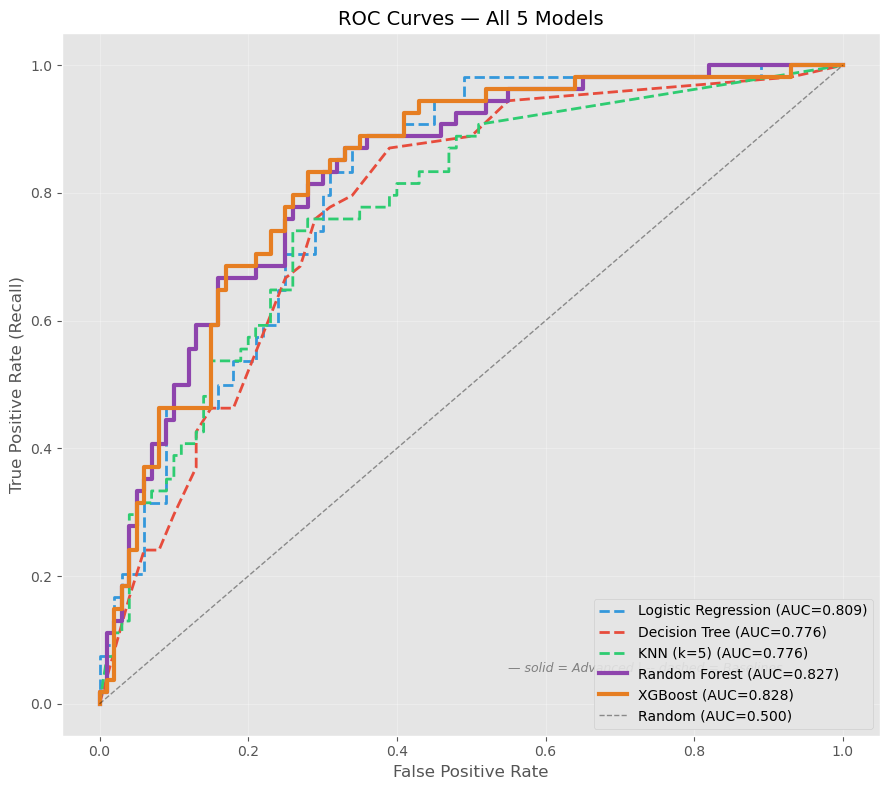

In [8]:
# ─────────────────────────────────────────────────────
# COMBINED ROC — all 5 models on one plot.
#
# Line styles:
#   Solid   → advanced models (RF, XGB)
#   Dashed  → baselines (LR, DT, KNN)
#
# This visual separation makes it easy to see how much
# the advanced models improved over baselines.
# ─────────────────────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 8))

style_map = {
    'Logistic Regression': ('#3498db', '--', 2.0),
    'Decision Tree'      : ('#e74c3c', '--', 2.0),
    'KNN (k=5)'          : ('#2ecc71', '--', 2.0),
    'Random Forest'      : ('#8e44ad', '-',  3.0),
    'XGBoost'            : ('#e67e22', '-',  3.0)
}

for name in all_probs:
    fpr, tpr, _ = roc_curve(y_test, all_probs[name])
    auc = roc_auc_score(y_test, all_probs[name])
    color, style, width = style_map[name]
    ax.plot(fpr, tpr, color=color, linestyle=style, linewidth=width,
            label=f'{name} (AUC={auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.4, label='Random (AUC=0.500)')

ax.set_xlabel('False Positive Rate', fontsize=12)
ax.set_ylabel('True Positive Rate (Recall)', fontsize=12)
ax.set_title('ROC Curves — All 5 Models', fontsize=14)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.3)

ax.text(0.55, 0.05, '— solid = Advanced | -- dashed = Baselines',
        fontsize=9, style='italic', color='gray')

plt.tight_layout()
plt.show()

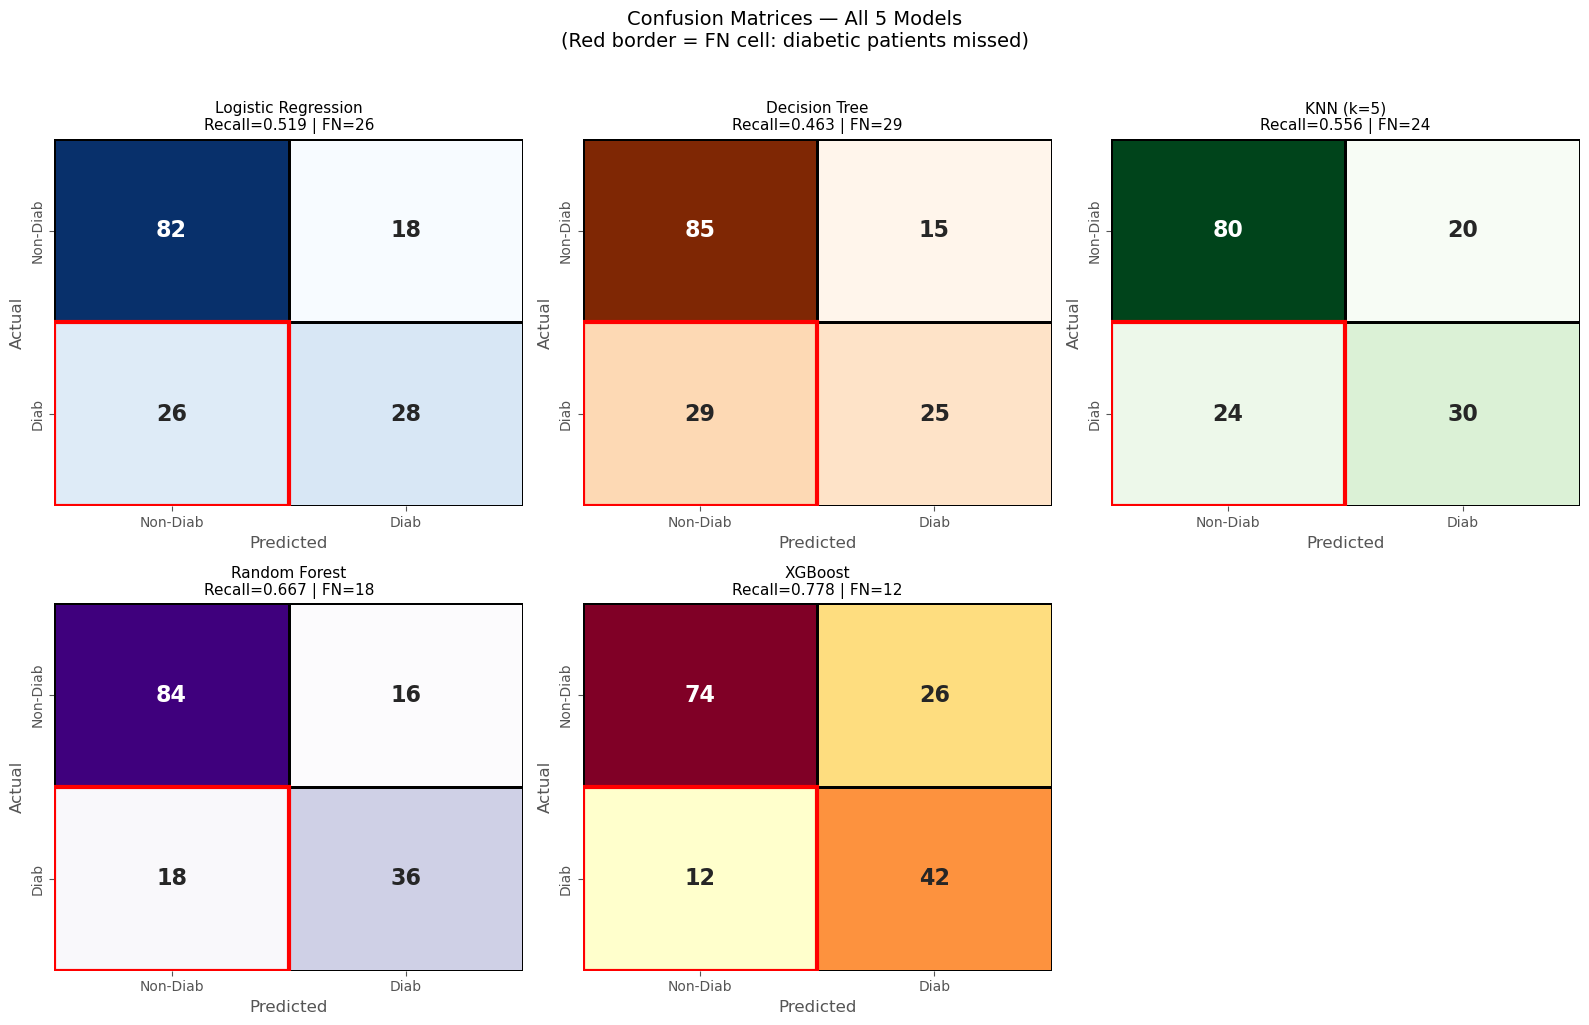

In [9]:
# ─────────────────────────────────────────────────────
# 2×3 grid of confusion matrices (5 models + 1 blank)
# Each uses a different colormap so they're visually distinct.
#
# The KEY number to watch in each matrix:
#   Bottom-left cell = FN (false negatives = diabetic patients MISSED)
#   We want this number as LOW as possible.
# ─────────────────────────────────────────────────────

colormaps  = ['Blues', 'Oranges', 'Greens', 'Purples', 'YlOrRd']
model_names = list(all_preds.keys())

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for i, name in enumerate(model_names):
    ax = axes[i]
    cm = confusion_matrix(y_test, all_preds[name])
    
    sns.heatmap(cm, annot=True, fmt='d', cmap=colormaps[i],
                xticklabels=['Non-Diab', 'Diab'],
                yticklabels=['Non-Diab', 'Diab'],
                ax=ax, linewidths=1, linecolor='black', cbar=False,
                annot_kws={'size': 16, 'weight': 'bold'})
    
    # Red border on FN cell (bottom-left)
    ax.add_patch(plt.Rectangle((0, 1), 1, 1, fill=False,
                               edgecolor='red', lw=3))
    
    fn = cm[1][0]
    tp = cm[1][1]
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    ax.set_title(f'{name}\nRecall={recall:.3f} | FN={fn}', fontsize=11)
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

axes[5].set_visible(False)

fig.suptitle('Confusion Matrices — All 5 Models\n(Red border = FN cell: diabetic patients missed)',
             fontsize=14, y=1.02)

plt.tight_layout()
plt.show()

In [10]:
# ─────────────────────────────────────────────────────
# REFERENCE CARD — exact formulas for every metric.
# ─────────────────────────────────────────────────────

lines = [
    '',
    '╔══════════════════════════════════════════════════════════════════════════════╗',
    '║                         METRIC DEFINITIONS & FORMULAS                       ║',
    '╠══════════════════════════════════════════════════════════════════════════════╣',
    '║                                                                              ║',
    '║  TP = True Positives   (diabetic correctly identified)                       ║',
    '║  TN = True Negatives   (non-diabetic correctly identified)                   ║',
    '║  FP = False Positives  (non-diabetic wrongly flagged as diabetic)            ║',
    '║  FN = False Negatives  (diabetic MISSED — most dangerous error)              ║',
    '║                                                                              ║',
    '║  Accuracy    = (TP + TN) / (TP + TN + FP + FN)                              ║',
    '║                → What fraction of ALL predictions were correct?              ║',
    '║                                                                              ║',
    '║  Precision   = TP / (TP + FP)                                                ║',
    '║                → Of everyone flagged diabetic, how many truly are?           ║',
    '║                                                                              ║',
    '║  Recall      = TP / (TP + FN)                                                ║',
    '║  (Sensitivity)→ Of all ACTUAL diabetics, how many did we catch?             ║',
    '║                  ★ HIGHEST PRIORITY for medical screening                    ║',
    '║                                                                              ║',
    '║  F1-Score    = 2 × (Precision × Recall) / (Precision + Recall)              ║',
    '║                → Harmonic mean. Penalises lopsided precision/recall.         ║',
    '║                                                                              ║',
    '║  MCC (Phi)   = (TP×TN - FP×FN) / √((TP+FP)(TP+FN)(TN+FP)(TN+FN))          ║',
    '║                → Range -1 to +1. Uses ALL 4 confusion matrix cells.         ║',
    '║                  Best single metric for imbalanced data.                     ║',
    '║                                                                              ║',
    '║  ROC-AUC     = Area under the ROC curve                                      ║',
    '║                → Discrimination across ALL thresholds. 0.5=random, 1=perfect ║',
    '║                                                                              ║',
    '╚══════════════════════════════════════════════════════════════════════════════╝',
    ''
]

print('\n'.join(lines))


╔══════════════════════════════════════════════════════════════════════════════╗
║                         METRIC DEFINITIONS & FORMULAS                       ║
╠══════════════════════════════════════════════════════════════════════════════╣
║                                                                              ║
║  TP = True Positives   (diabetic correctly identified)                       ║
║  TN = True Negatives   (non-diabetic correctly identified)                   ║
║  FP = False Positives  (non-diabetic wrongly flagged as diabetic)            ║
║  FN = False Negatives  (diabetic MISSED — most dangerous error)              ║
║                                                                              ║
║  Accuracy    = (TP + TN) / (TP + TN + FP + FN)                              ║
║                → What fraction of ALL predictions were correct?              ║
║                                                                              ║
║  Precision   = TP / (TP + F

In [11]:
# ─────────────────────────────────────────────────────
# FINAL MODEL CARD — the definitive summary.
# This is what the backend API and the mobile app reference.
# ─────────────────────────────────────────────────────

# Identify overall winner (by recall, then F1, then MCC)
winner_name = results_df['Recall'].idxmax()
winner_row  = results_df.loc[winner_name]

# If recall is tied, break with F1
max_recall = results_df['Recall'].max()
tied = results_df[results_df['Recall'] == max_recall]
if len(tied) > 1:
    winner_name = tied['F1-Score'].idxmax()
    winner_row  = results_df.loc[winner_name]

# Build the model card line by line (avoids triple-quote escaping issues)
card = [
    '',
    '╔═══════════════════════════════════════════════════════════════════╗',
    '║                    FINAL MODEL CARD                               ║',
    '║               DiabetScope-AI v1.0                                 ║',
    '╠═══════════════════════════════════════════════════════════════════╣',
    '║                                                                   ║',
    f'║  Selected Model : {winner_name:<48} ║',
    '║  Selection Rule : Recall > F1-Score > MCC (medical priority)     ║',
    '║                                                                   ║',
    '║  ── Performance Metrics ──                                        ║',
    f'║  Recall (Sensitivity) : {winner_row["Recall"]:.4f}                                    ║',
    f'║  Precision            : {winner_row["Precision"]:.4f}                                    ║',
    f'║  F1-Score             : {winner_row["F1-Score"]:.4f}                                    ║',
    f'║  MCC (Phi Coeff)      : {winner_row["MCC (Phi)"]:.4f}                                    ║',
    f'║  ROC-AUC              : {winner_row["ROC-AUC"]:.4f}                                    ║',
    f'║  Accuracy             : {winner_row["Accuracy"]:.4f}                                    ║',
    '║                                                                   ║',
    '║  ── Dataset Info ──                                               ║',
    '║  Source   : Pima Indians Diabetes Database                        ║',
    '║  Samples  : 768 (614 train, 154 test)                             ║',
    '║  Features : 11 (8 original + 3 engineered interactions)          ║',
    '║  Split    : 80/20 stratified (seed=42)                            ║',
    '║                                                                   ║',
    '║  ── Preprocessing ──                                              ║',
    '║  • Zeros → NaN → Median imputation                               ║',
    '║  • IQR-based outlier capping (winsorization)                      ║',
    '║  • 3 interaction features engineered                              ║',
    '║  • StandardScaler (fit on train only)                             ║',
    '║                                                                   ║',
    '║  ⚠  MEDICAL DISCLAIMER                                            ║',
    '║  This model is a SCREENING tool only. It does not replace         ║',
    '║  clinical diagnosis. All positive predictions must be             ║',
    '║  confirmed by a qualified healthcare professional.                ║',
    '║                                                                   ║',
    '╚═══════════════════════════════════════════════════════════════════╝',
    ''
]

print('\n'.join(card))


╔═══════════════════════════════════════════════════════════════════╗
║                    FINAL MODEL CARD                               ║
║               DiabetScope-AI v1.0                                 ║
╠═══════════════════════════════════════════════════════════════════╣
║                                                                   ║
║  Selected Model : XGBoost                                          ║
║  Selection Rule : Recall > F1-Score > MCC (medical priority)     ║
║                                                                   ║
║  ── Performance Metrics ──                                        ║
║  Recall (Sensitivity) : 0.7778                                    ║
║  Precision            : 0.6176                                    ║
║  F1-Score             : 0.6885                                    ║
║  MCC (Phi Coeff)      : 0.4975                                    ║
║  ROC-AUC              : 0.8281                                    ║
║  Accuracy        

In [12]:
# ─────────────────────────────────────────────────────
# SAVE the final comparison as JSON for the README
# ─────────────────────────────────────────────────────

import os
os.makedirs('../artifacts/reports', exist_ok=True)

final_report = {
    'selected_model': winner_name,
    'selection_criteria': 'Recall > F1-Score > MCC (medical screening priority)',
    'all_models': all_results,
    'dataset': {
        'source': 'Pima Indians Diabetes Database',
        'total_samples': 768,
        'train_samples': len(y_train),
        'test_samples': len(y_test),
        'features_original': 8,
        'features_engineered': 3,
        'features_total': 11
    }
}

with open('../artifacts/reports/final_evaluation.json', 'w') as f:
    json.dump(final_report, f, indent=2)

print('✅ Final evaluation report saved → artifacts/reports/final_evaluation.json')
print('')
print('🎉 Pipeline complete. All 5 notebooks executed successfully.')

✅ Final evaluation report saved → artifacts/reports/final_evaluation.json

🎉 Pipeline complete. All 5 notebooks executed successfully.
